# Genetic Rock Paper Scissors

The original paper shows how, in a _three-way_ prey-predator model, the
unexpected emerging behavior is a sort of _survival of the weakest_, where the
least aggressive species are the ones the most likely will have an higher
population density.

The model does not involve movement but only space conquering by hunting a
nearby cell, which will host the offspring of the predator. The offspring
inherit the invasion probability from the father

- Just by copying it:
  $$ p_\text{new} = p_\text{old} $$
- With a random mutation:
  $$ p_\text{new} = p_\text{old} + \varepsilon $$
  with $\varepsilon \sim \cal{N} (0, 0.05)$

The study shows mainly two cases: 

- Two of the three species invasion probability are held constant, while the
  third is free to evolve through random mutations.
- All three species are free to mutate.

The paper also says how the mutation, in general, drive the population to be
more aggressive on average, that results in:

- A reduced population of the specie free to evolve (first case).
- A dynamical equilibrium, made possible by all three species reaching maximal
  aggression (second case).

## Paper Results Reproduction

The first thing to do is to have a baseline by reproducing the dynamics
described in the paper on a $50 \times 50$ and a maximum of $2000$ epochs
simulation. 

The grid is randomly initialized by sampling one of the three species for each
cell with equal probability.

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd


def plot_densities(data: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 4), dpi=200)
    axes = axes.flat
    fig.suptitle("Population Densities")

    for i in range(4):
        df = data[data["seed"] == i]
        axes[i].plot(df["epoch"], df["R_density"], c="red", label="rock")
        axes[i].plot(df["epoch"], df["P_density"], c="blue", label="paper")
        axes[i].plot(df["epoch"], df["S_density"], c="green", label="scissors")
        if i == 2 or i == 3:
            axes[i].set_xlabel("Epoch")
        if i == 0 or i == 2:
            axes[i].set_ylabel("Count")
        axes[i].grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.05),
    )
    plt.tight_layout()
    plt.show()


def plot_average_invasions(data: pd.DataFrame) -> None:
    # Average invasion rate
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 4), dpi=200)
    axes = axes.flat
    fig.suptitle("Mean Invasion Probability")

    for i in range(4):
        df = data[data["seed"] == i]
        axes[i].plot(df["epoch"], df["R_invasion"], c="red", label="rock")
        axes[i].plot(df["epoch"], df["P_invasion"], c="blue", label="paper")
        axes[i].plot(df["epoch"], df["S_invasion"], c="green", label="scissors")
        axes[i].axhline(1.0, ls="--", c="gray", label="max invasion")
        if i == 2 or i == 3:
            axes[i].set_xlabel("Epoch")
        if i == 0 or i == 2:
            axes[i].set_ylabel("Invasion")
        axes[i].grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, -0.05),
    )
    plt.tight_layout()
    plt.show()


def plot_average_age(data: pd.DataFrame) -> None:
    # Average age
    fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 4), dpi=200)
    axes = axes.flat
    fig.suptitle("Mean Population Age")

    for i in range(4):
        df = data[data["seed"] == i]
        axes[i].plot(df["epoch"], df["R_age"], c="red", label="rock")
        axes[i].plot(df["epoch"], df["P_age"], c="blue", label="paper")
        axes[i].plot(df["epoch"], df["S_age"], c="green", label="scissors")
        if i == 2 or i == 3:
            axes[i].set_xlabel("Epoch")
        if i == 0 or i == 2:
            axes[i].set_ylabel("Age")
        axes[i].grid(True)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.05),
    )
    plt.tight_layout()
    plt.show()


### Inheritance

The first case of study assigns at each specie individual an invasion
probability, which will inhertied by their offsprings after the reproduction.

Here the goal is just to reproduce the main result of the paper (survival of the
weakest), by assigning a lower invasion probability to one of the three species
and see if in the end it has the highest population density.

In [ ]:
in_df = pd.read_csv("results/inheritance.csv")
in_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy
0,799,863,838,0.2,0.5,0.5,0.000000,0.000000,0.000000,0,0,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
1,737,840,923,0.2,0.5,0.5,1.000000,1.000000,1.000000,1,0,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
2,673,810,1017,0.2,0.5,0.5,1.928678,1.871605,1.855457,2,0,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
3,631,756,1113,0.2,0.5,0.5,2.738510,2.634921,2.595687,3,0,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
4,598,700,1202,0.2,0.5,0.5,3.546823,3.355714,3.308652,4,0,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,712,429,1359,0.2,0.5,0.5,15.262640,7.620047,14.681383,495,3,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
1996,718,412,1370,0.2,0.5,0.5,15.154596,7.832524,15.003650,496,3,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
1997,714,400,1386,0.2,0.5,0.5,15.275910,7.807500,15.266955,497,3,50,0.2,0.5,0.5,inheritance,inheritance,inheritance
1998,713,391,1396,0.2,0.5,0.5,14.992987,7.687980,15.375358,498,3,50,0.2,0.5,0.5,inheritance,inheritance,inheritance


In [88]:
ina_df = pd.read_csv("results/agent_inheritance.csv")
ina_df

,specie,age,invasion,seed
0,scissors,0,0.5,0
1,scissors,0,0.5,0
2,paper,0,0.5,0
3,rock,0,0.2,0
4,paper,0,0.5,0
...,...,...,...,...
4999995,scissors,11,0.5,3
4999996,scissors,8,0.5,3
4999997,scissors,4,0.5,3
4999998,paper,11,0.5,3


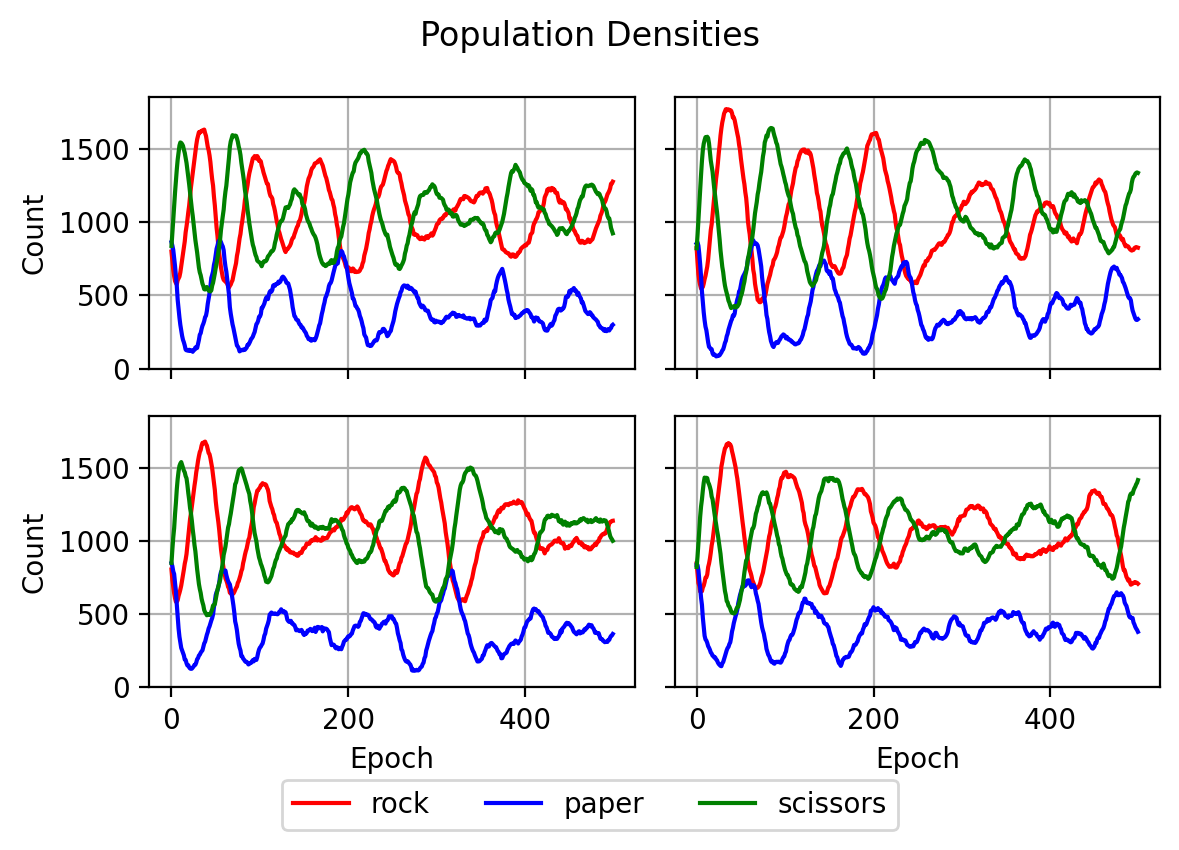

In [ ]:
plot_densities(in_df)

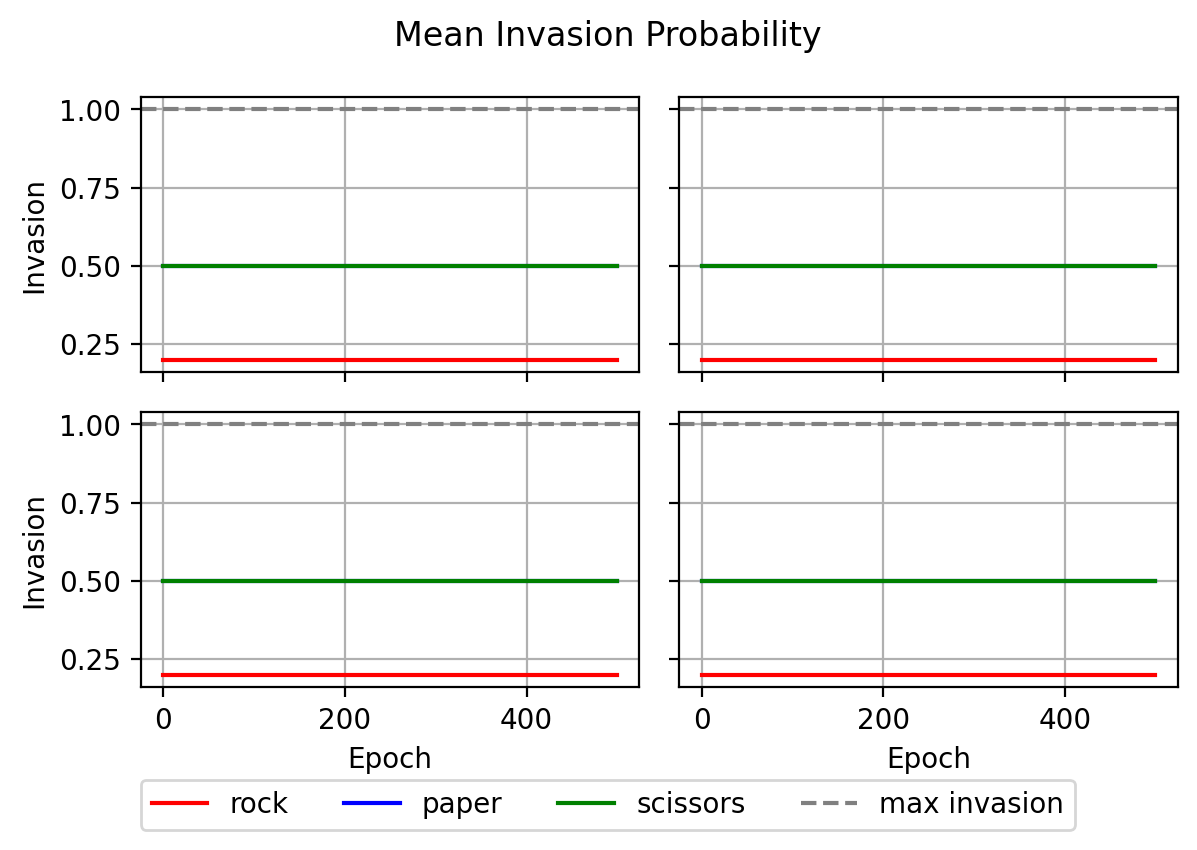

In [ ]:
plot_average_invasions(in_df)

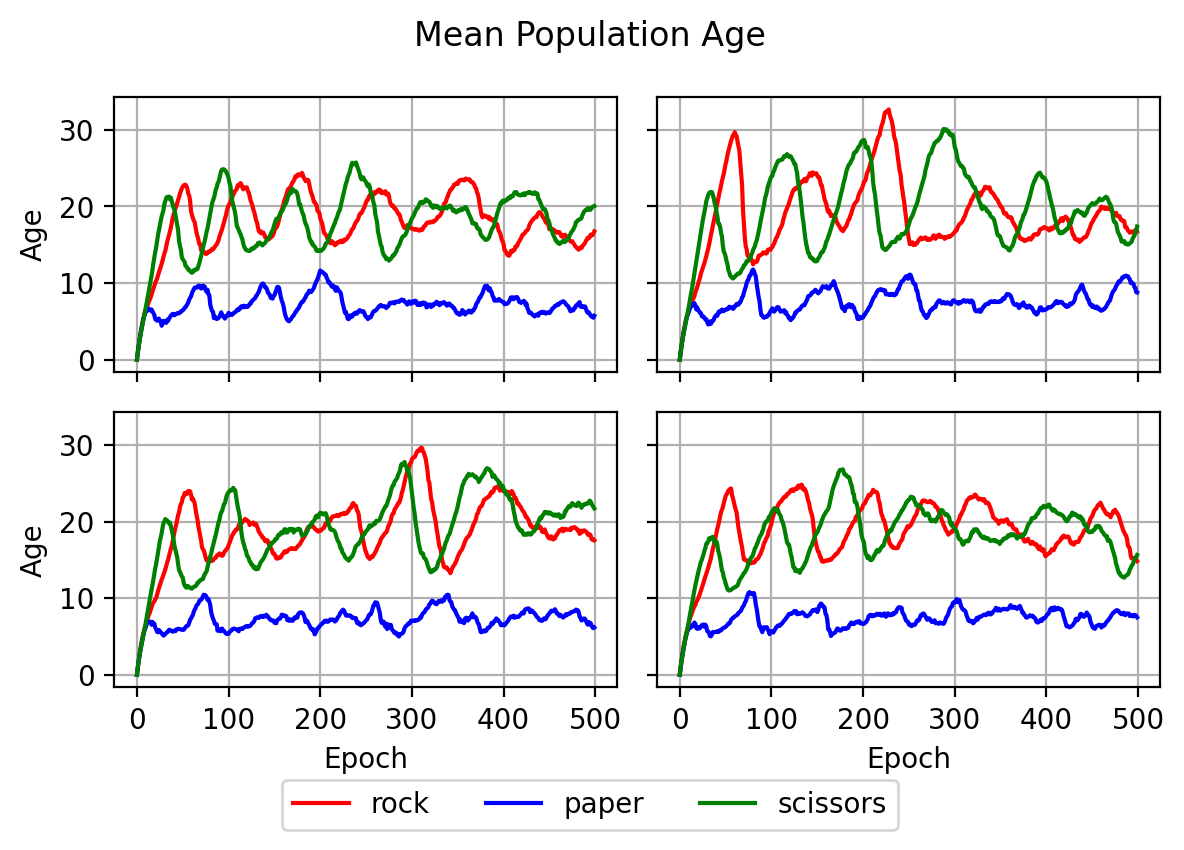

In [ ]:
plot_average_age(in_df)

### Stochastic Mutation of 1 Specie

The other main result shown was obtained by keeping two species invasion
probabilites fixed, while the third can mutate.

Here the end result can vary, depending on initial conditions and initial
invasion probabilities assigned to each specie.

In the following simulations are shown two main scenarios:

- Every specie starts with an initial invasion rate of $0.5$.
- The evolvable specie starts with a low invasion rate of $0.2$.

The two models might converge to the same result, since in the paper is said
that the mutated specie tends to be more aggressive in the end.

In [59]:
s1_df = pd.read_csv("results/stochastic1.csv")
s1_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,799,863,838,0.200000,0.5,0.5,0.000000,0.000000,0.000000,0,0,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1,734,847,919,0.199933,0.5,0.5,1.000000,1.000000,1.000000,1,0,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
2,676,815,1009,0.201075,0.5,0.5,1.923077,1.876074,1.857284,2,0,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
3,614,768,1118,0.201933,0.5,0.5,2.781759,2.626302,2.598390,3,0,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
4,579,705,1216,0.201410,0.5,0.5,3.592401,3.354610,3.302632,4,0,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,829,1113,558,0.819656,0.5,0.5,8.454765,9.003594,6.322581,495,3,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1996,818,1117,565,0.819957,0.5,0.5,8.561125,9.123545,6.430088,496,3,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1997,798,1133,569,0.822473,0.5,0.5,8.739348,9.240071,6.520211,497,3,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05
1998,798,1153,549,0.823745,0.5,0.5,8.829574,9.515178,6.426230,498,3,50,0.2,0.5,0.5,stochastic,inheritance,inheritance,0.05


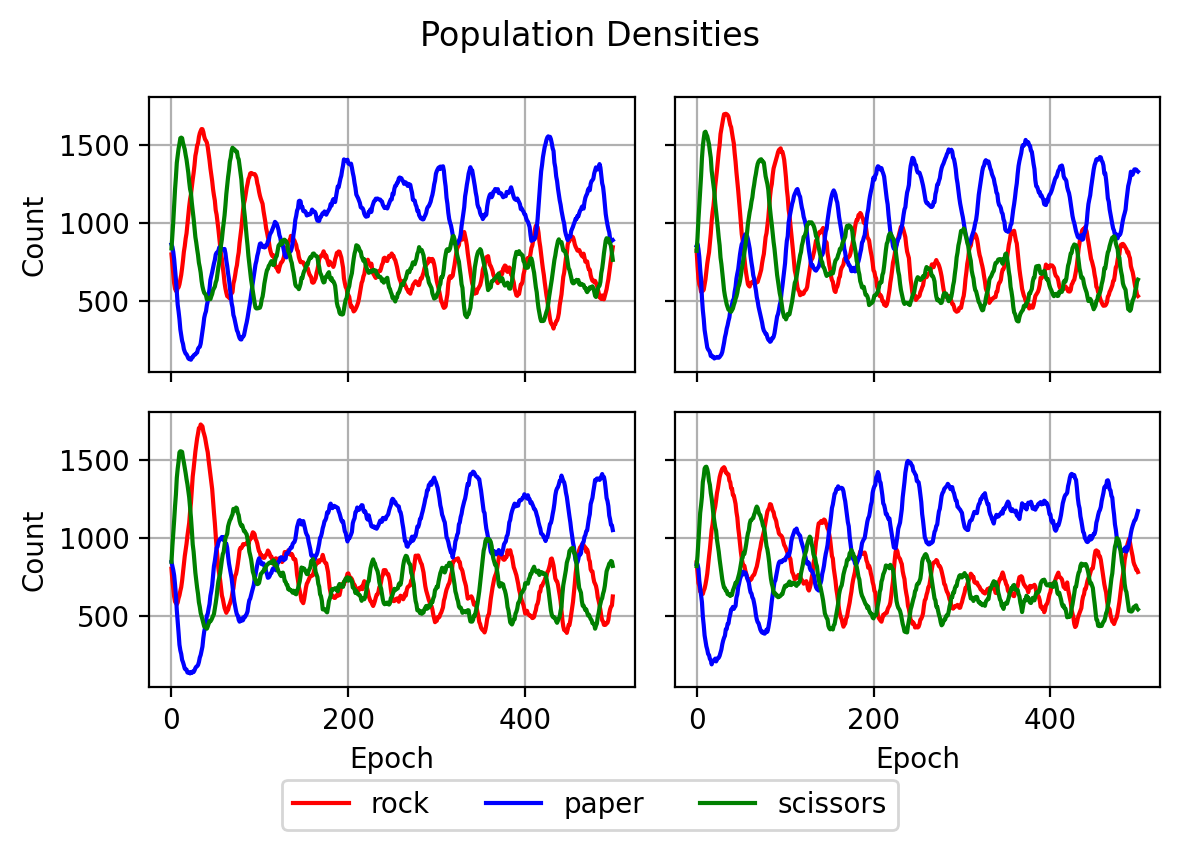

In [60]:
plot_densities(s1_df)

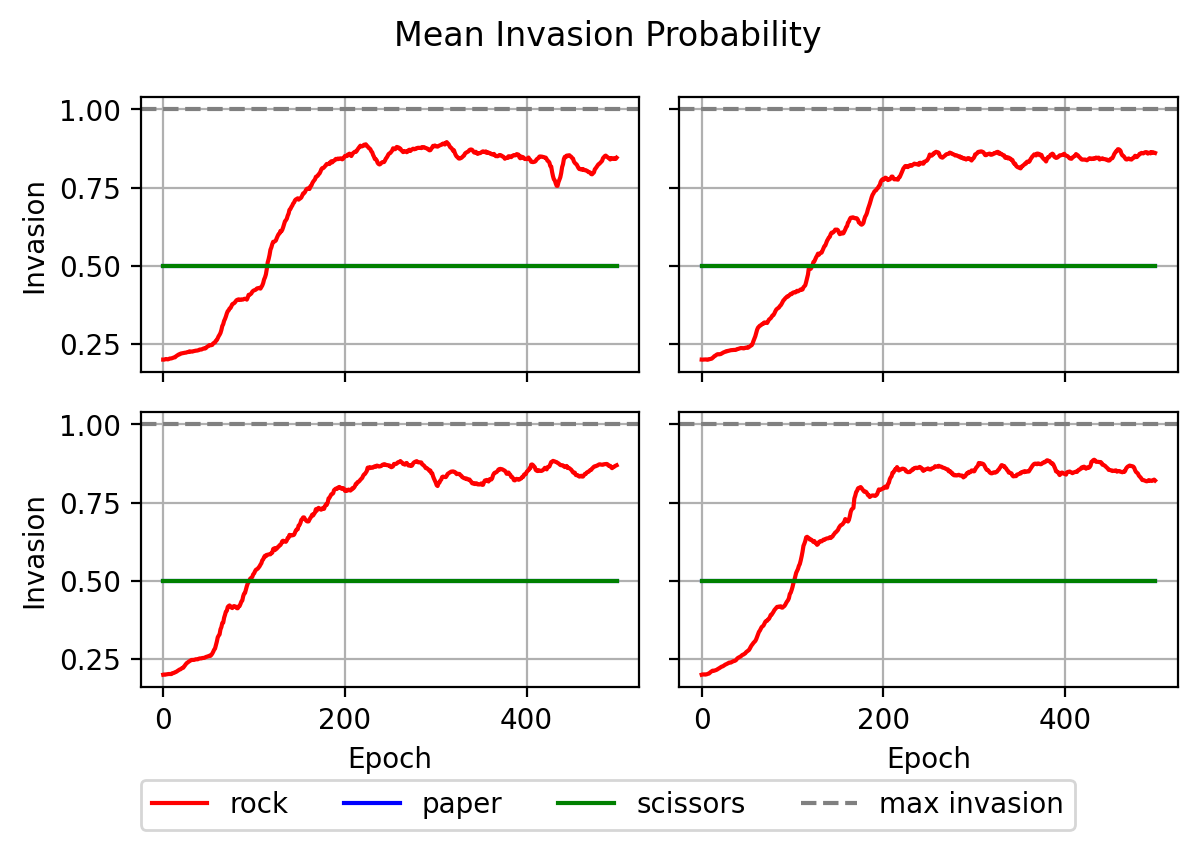

In [61]:
plot_average_invasions(s1_df)

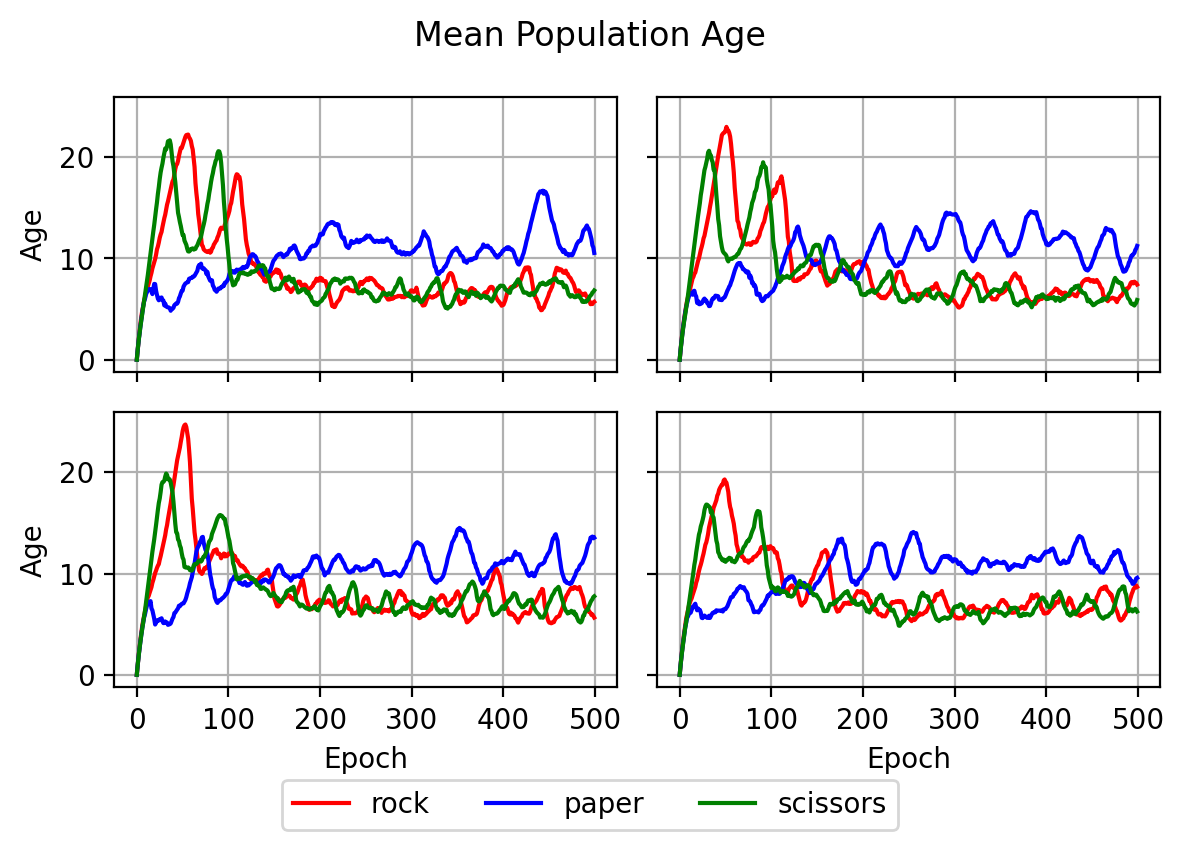

In [62]:
plot_average_age(s1_df)

Also for this setup nothing really surprising: since rock starts with a low
invasion probability, its population grows fast but more aggressive over time.

After few iterations the invasion rate is already at $0.5$ and after a few more
reaches values between $0.8$ and $0.9$ that, depending on the specific case,
leads to a decrease in population

### Stochastic Mutation of 3 Species

Another experiment consists in let all three species evolve via random
mutations, in the paper is mentioned how an equilibrium through maximal
aggression should be reached. 

It follows just a simulation in which every specie starts with an invasion
probability of $0.1$.

In [63]:
s3_df = pd.read_csv("results/stochastic3.csv")
s3_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1,790,868,842,0.501372,0.500332,0.499548,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
2,774,843,883,0.502400,0.498933,0.500422,1.874677,1.867141,1.842582,2,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
3,777,828,895,0.502907,0.498998,0.500429,2.574003,2.609903,2.572067,3,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
4,787,834,879,0.502436,0.499762,0.500926,3.180432,3.251799,3.285552,4,0,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,540,967,993,0.877663,0.872091,0.864158,6.179630,6.412616,4.744209,495,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1996,530,896,1074,0.873684,0.872488,0.859470,5.709434,6.458705,4.833333,496,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1997,526,830,1144,0.875531,0.872967,0.860435,5.250951,6.449398,5.000000,497,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05
1998,559,745,1196,0.874273,0.874730,0.861548,4.867621,6.363758,5.193980,498,3,50,0.5,0.5,0.5,stochastic,stochastic,stochastic,0.05


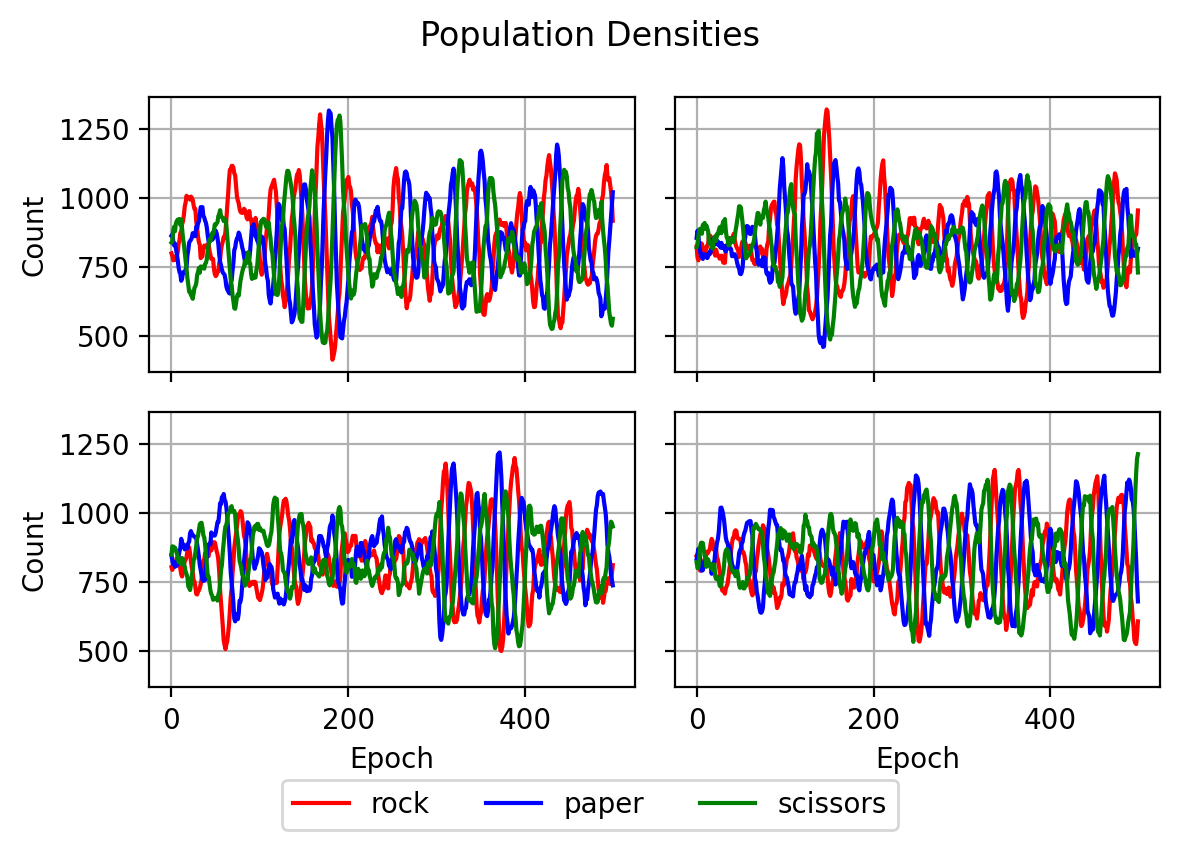

In [64]:
plot_densities(s3_df)

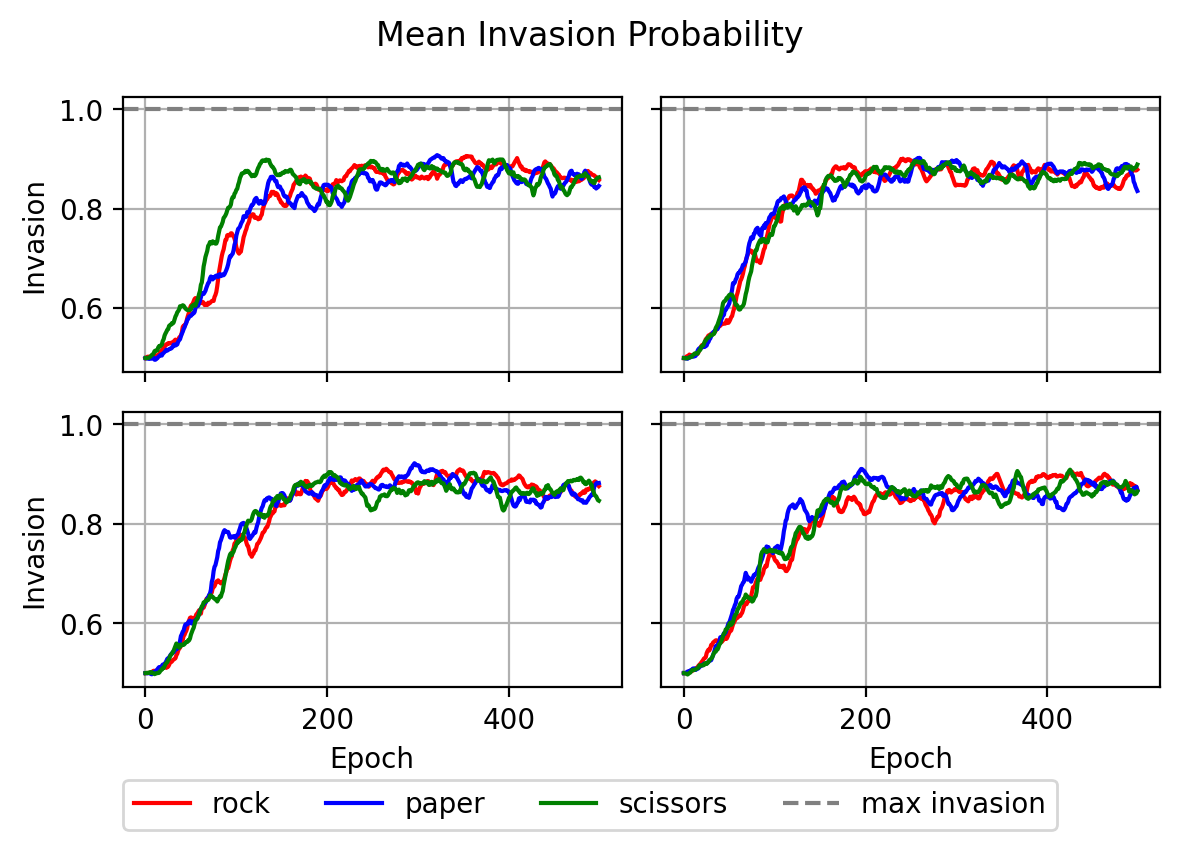

In [65]:
plot_average_invasions(s3_df)

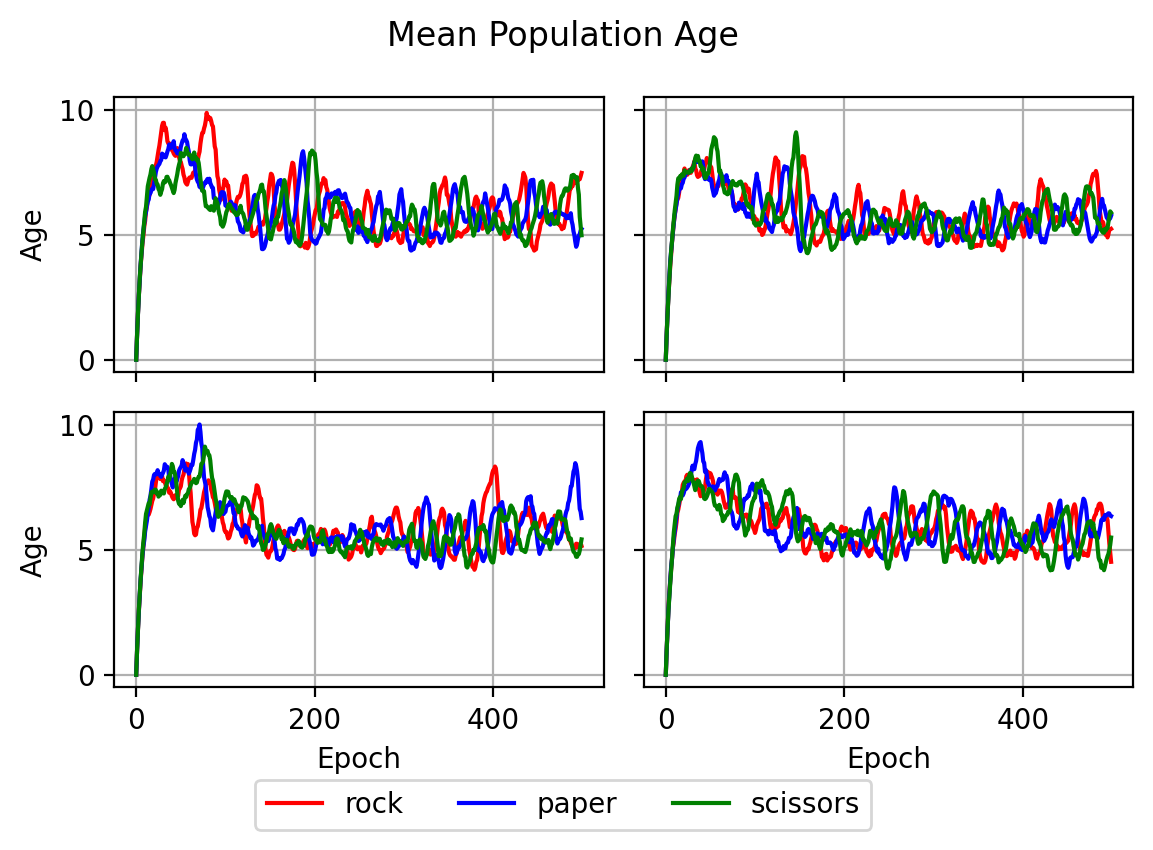

In [66]:
plot_average_age(s3_df)

## Proposed Extension

The proposed extension tries to introduce a more structured evolution approach,
by adding a **mating** mechasism based on a _fitness_ value (the age) and the
distance from the predator.

The idea is based on the assumption that older individuals may have a better
survival strategy. Therefore, when an individual hunts a prey, produces an
offspring with a invasion rate computed as the weighted mean between its
father's and a nearby individual with (hopefully) high fitness.

The idea is to sample an individual of the same specie within a certain radius
in order to maintain the simulation dynamics local. The final mate for
reproduction is sampled, weighted by its fitness.

The candidates are chosen within the radius accordingly with the Chebyshev
distance, which basically defines squared rings around the individual.

![Chebyshev Distance](images/chebyshev_distance.png)

### Genetic vs Direct Inheritance

The first simulation type compares the new approach with the old
inheritance-based evolution without mutation.

In [67]:
g1_2i_df = pd.read_csv("results/genetic3_i2.csv")
g1_2i_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.5,0.5,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
1,796,857,847,0.500596,0.5,0.5,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
2,780,857,863,0.500358,0.5,0.5,1.861538,1.857643,1.851680,2,0,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
3,787,849,864,0.499887,0.5,0.5,2.576874,2.614841,2.601852,3,0,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
4,779,846,875,0.499243,0.5,0.5,3.220796,3.247045,3.244571,4,0,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,991,872,637,0.553050,0.5,0.5,9.467205,8.083716,8.623234,495,3,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
1996,1005,898,597,0.553804,0.5,0.5,9.409950,8.279510,8.321608,496,3,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
1997,983,928,589,0.554723,0.5,0.5,9.456765,8.312500,8.020374,497,3,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10
1998,957,944,599,0.553501,0.5,0.5,9.541275,8.454449,7.712855,498,3,50,0.5,0.5,0.5,genetic,inheritance,inheritance,0.05,10


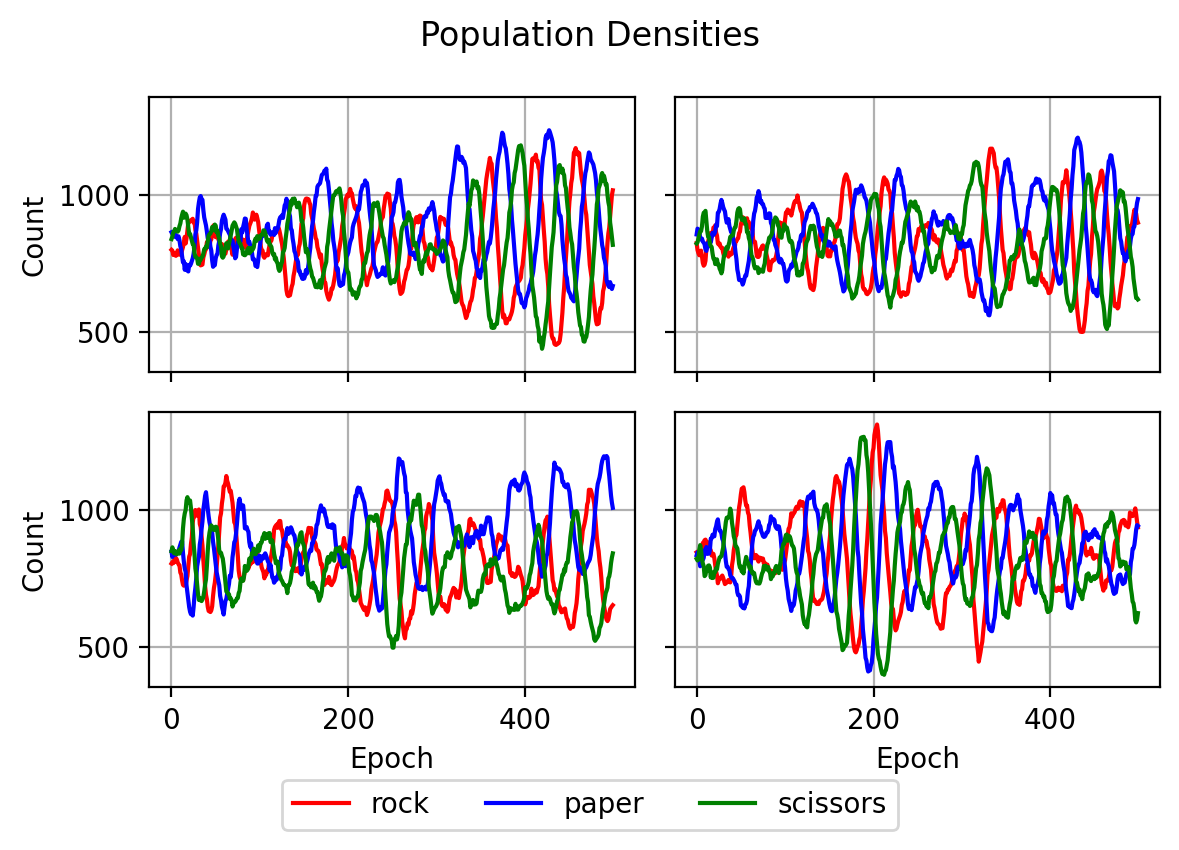

In [68]:
plot_densities(g1_2i_df)

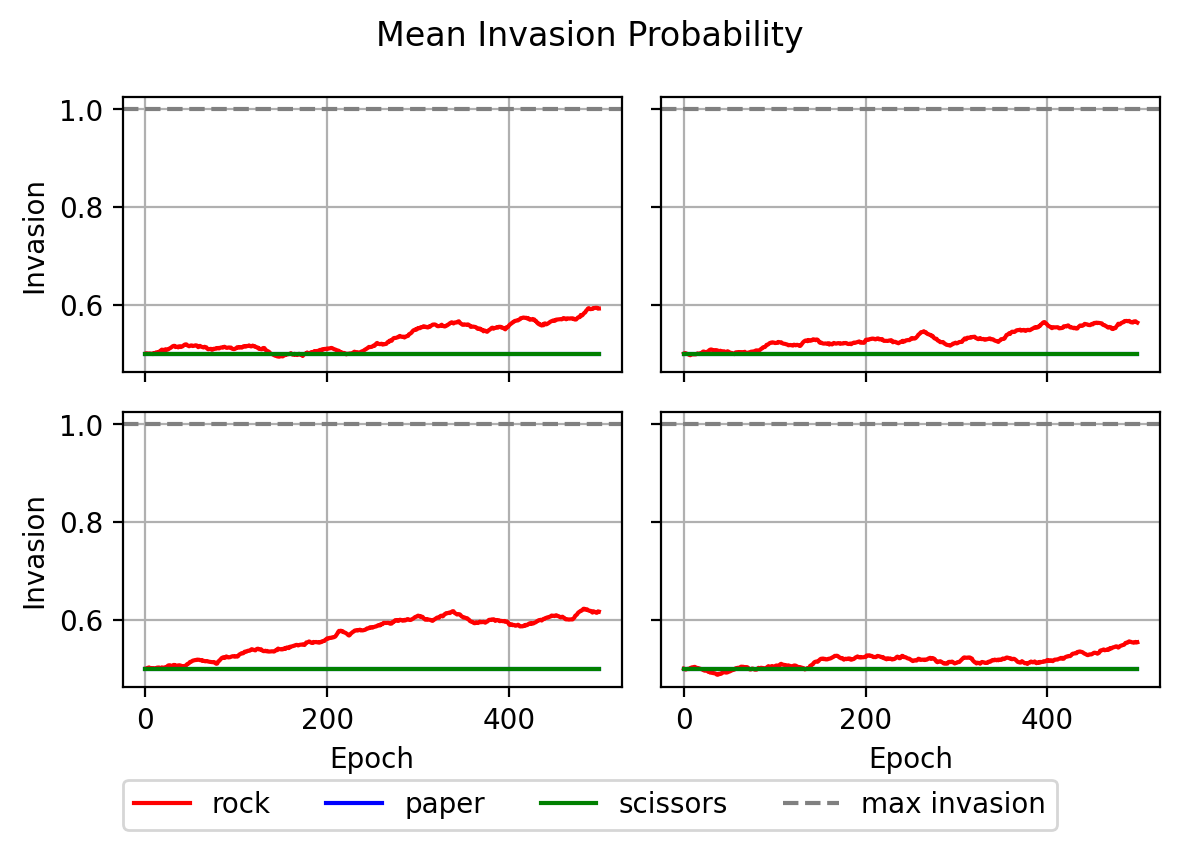

In [69]:
plot_average_invasions(g1_2i_df)

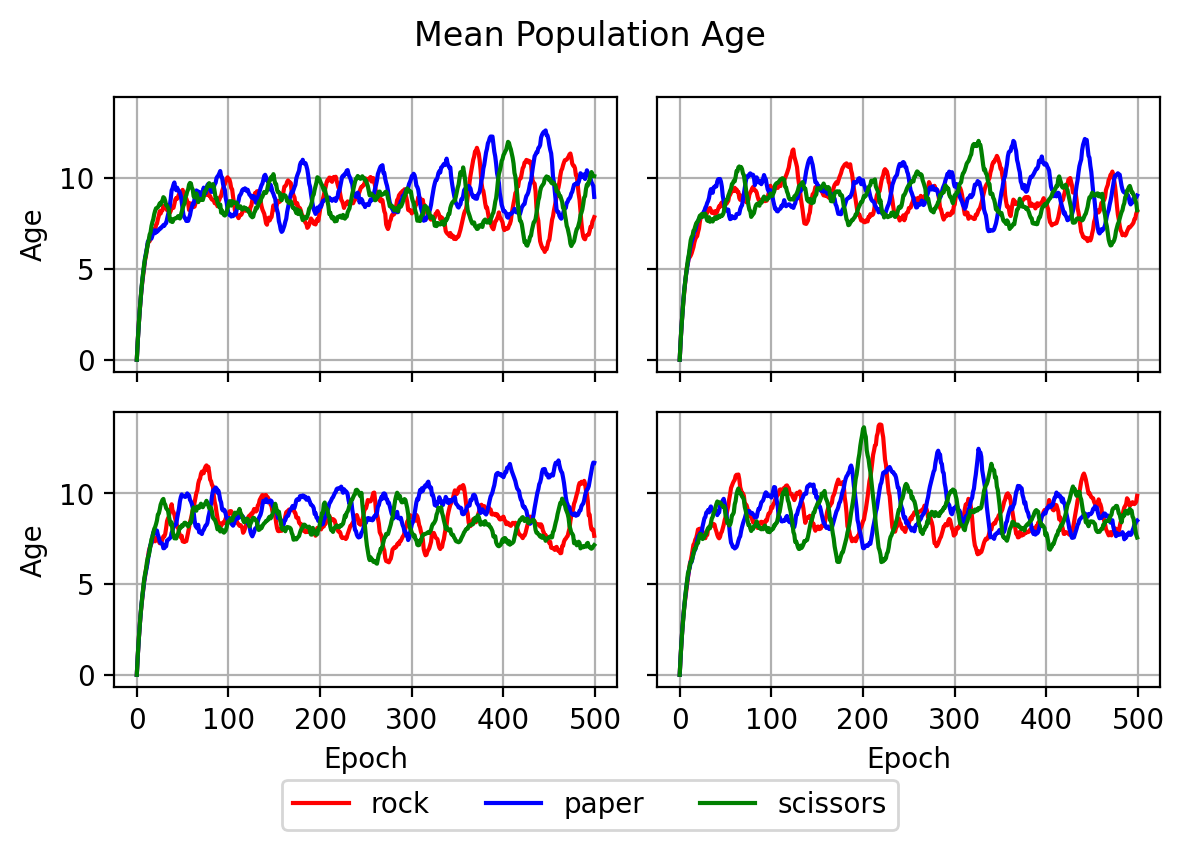

In [70]:
plot_average_age(g1_2i_df)

As we can see now the invasion probability of the optimized specie grows slower than before.

### Genetic vs Stochastic

The other comparison was done by letting two of the species evolve by stochastic mutations, while the third was optimized with the genetic approach.

In [71]:
g1_2s_df = pd.read_csv("results/genetic3_s2.csv")
g1_2s_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1,780,866,854,0.500403,0.499488,0.500132,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
2,778,823,899,0.500517,0.500039,0.500329,1.863753,1.872418,1.829811,2,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
3,780,801,919,0.500957,0.500158,0.499801,2.597436,2.630462,2.589771,3,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
4,797,786,917,0.501021,0.500173,0.501751,3.193225,3.267176,3.249727,4,0,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1001,649,850,0.676407,0.815556,0.838548,6.825175,5.859784,6.932941,495,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1996,1020,657,823,0.678004,0.819565,0.840106,6.776471,5.669711,6.867558,496,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1997,1020,663,817,0.678621,0.823487,0.840072,6.866667,5.574661,6.784578,497,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10
1998,1015,649,836,0.678226,0.826492,0.837689,7.016749,5.520801,6.570574,498,3,50,0.5,0.5,0.5,genetic,stochastic,stochastic,0.05,10


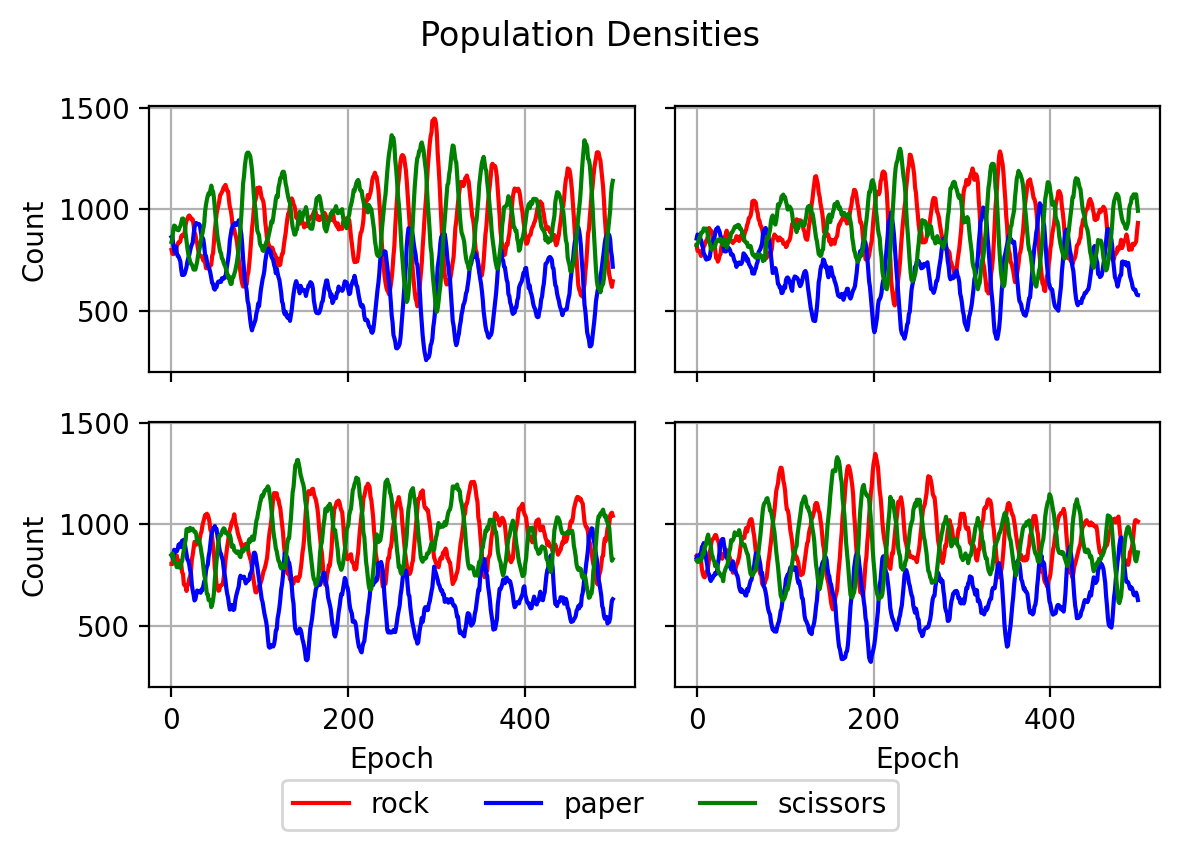

In [72]:
plot_densities(g1_2s_df)

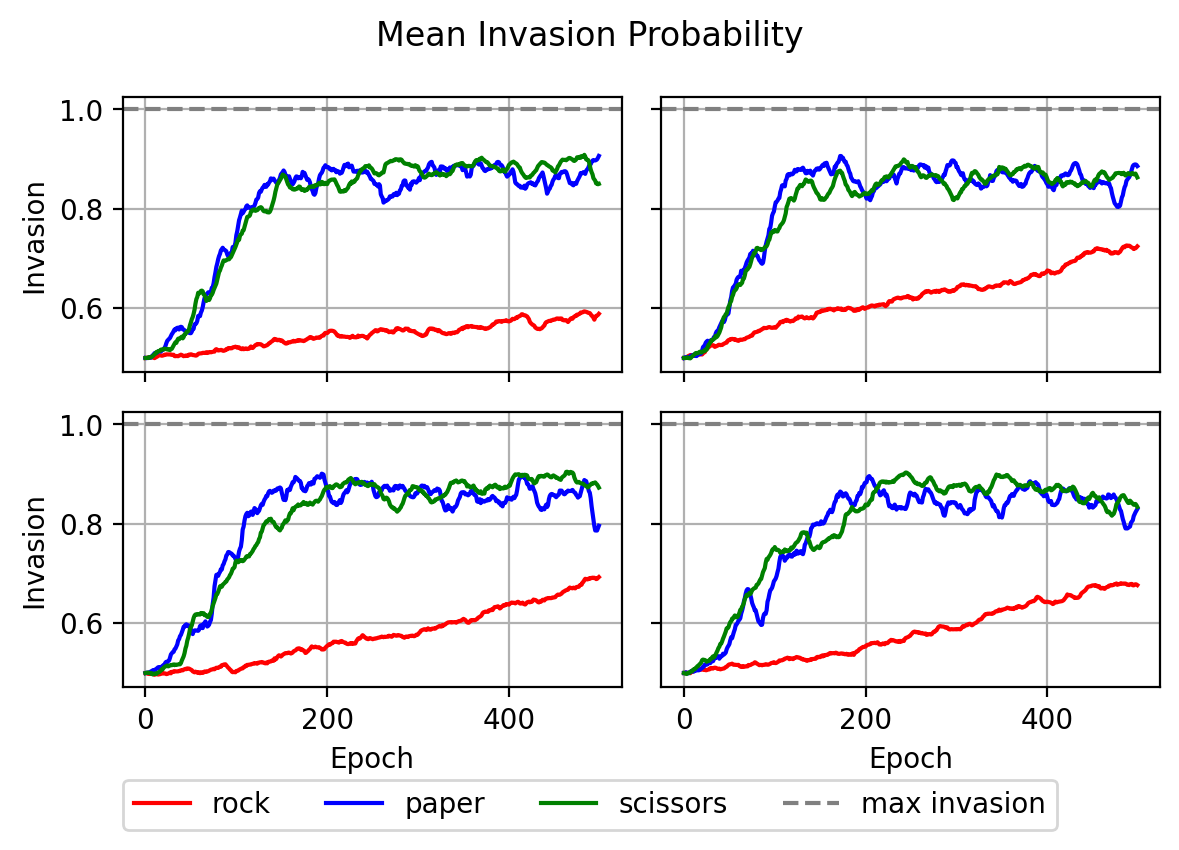

In [73]:
plot_average_invasions(g1_2s_df)

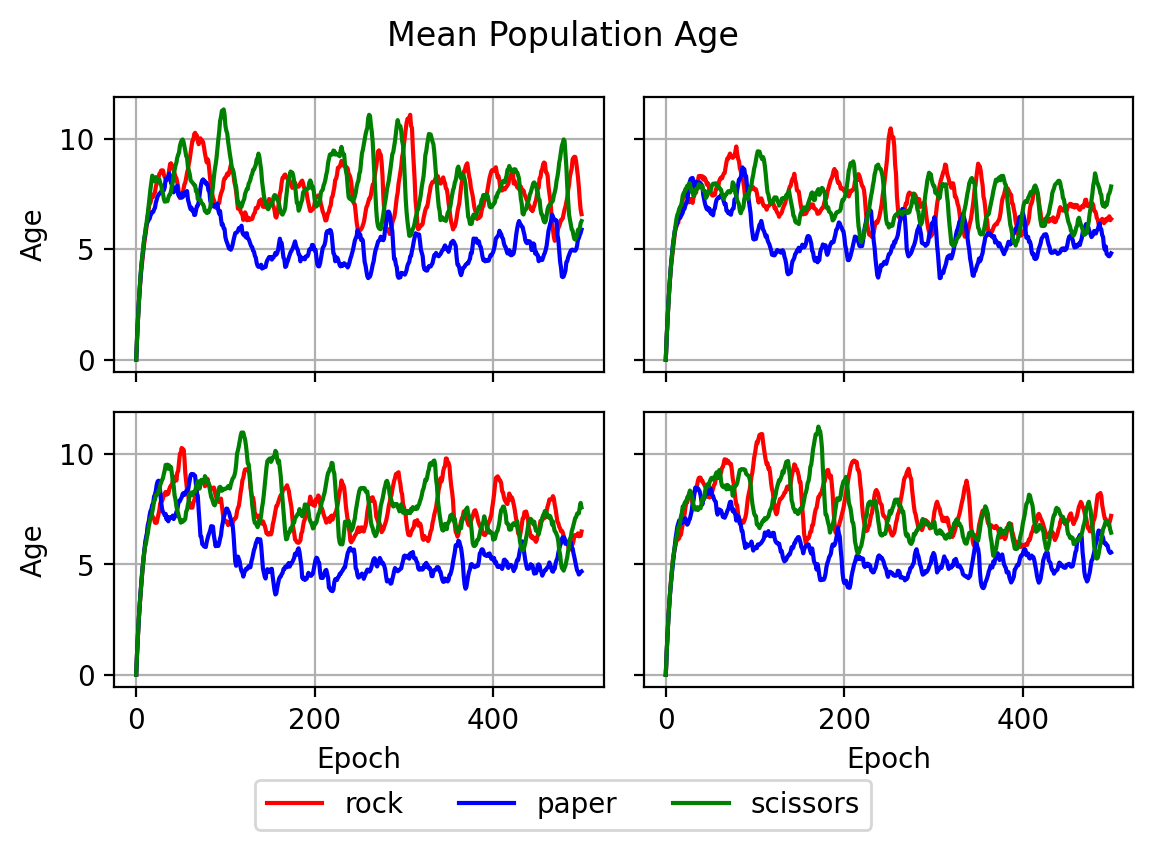

In [74]:
plot_average_age(g1_2s_df)

In [75]:
g3_r10_df = pd.read_csv("results/genetic3_r10.csv")
g3_r10_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1,773,869,858,0.499807,0.499916,0.500509,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
2,790,841,869,0.500042,0.499636,0.501086,1.840506,1.869203,1.845800,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
3,802,811,887,0.499921,0.499785,0.501310,2.577307,2.646116,2.580609,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
4,856,792,852,0.500354,0.499092,0.501880,3.158879,3.347222,3.265258,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1033,886,581,0.552364,0.556169,0.545440,9.074540,7.357788,7.641997,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1996,986,922,592,0.553613,0.554193,0.543990,9.310345,7.390456,7.508446,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1997,958,939,603,0.553878,0.552675,0.544516,9.346555,7.560170,7.412935,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10
1998,919,986,595,0.554948,0.552696,0.544728,9.346028,7.589249,7.205042,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,10


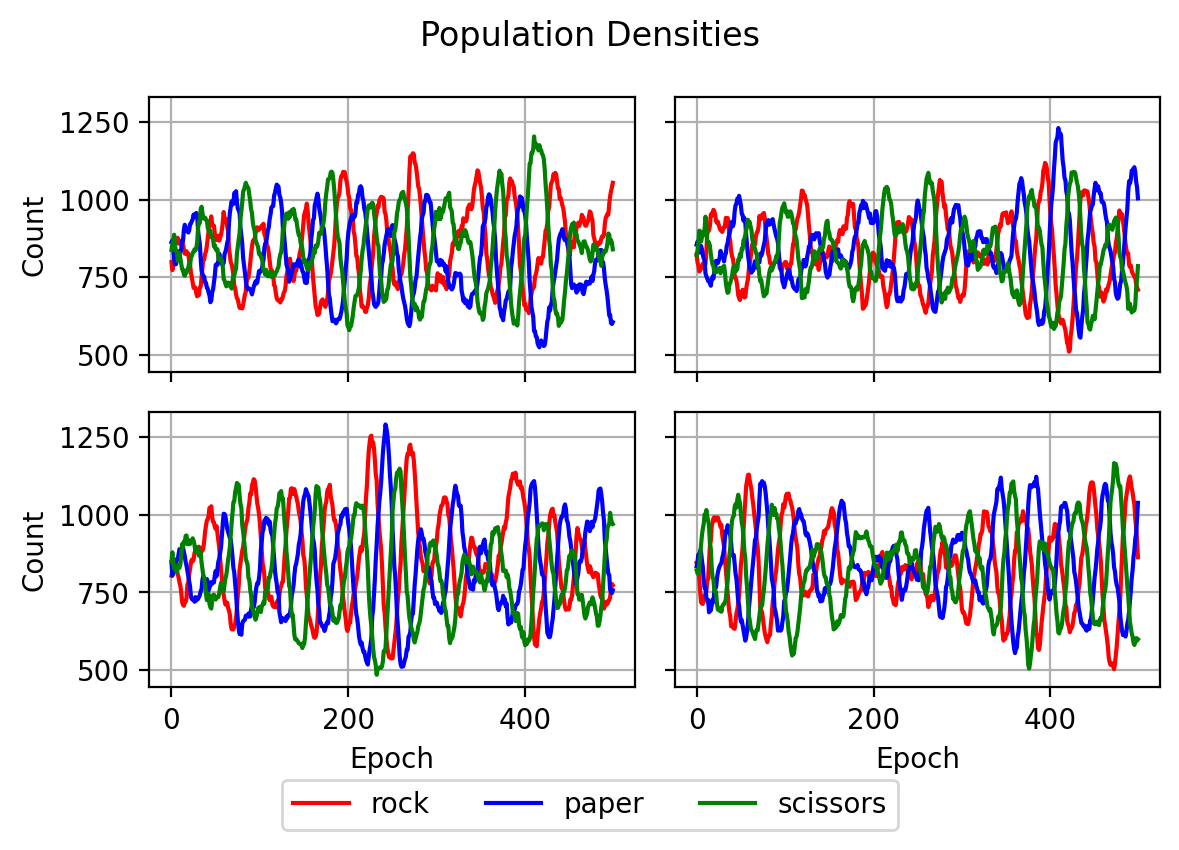

In [76]:
plot_densities(g3_r10_df)

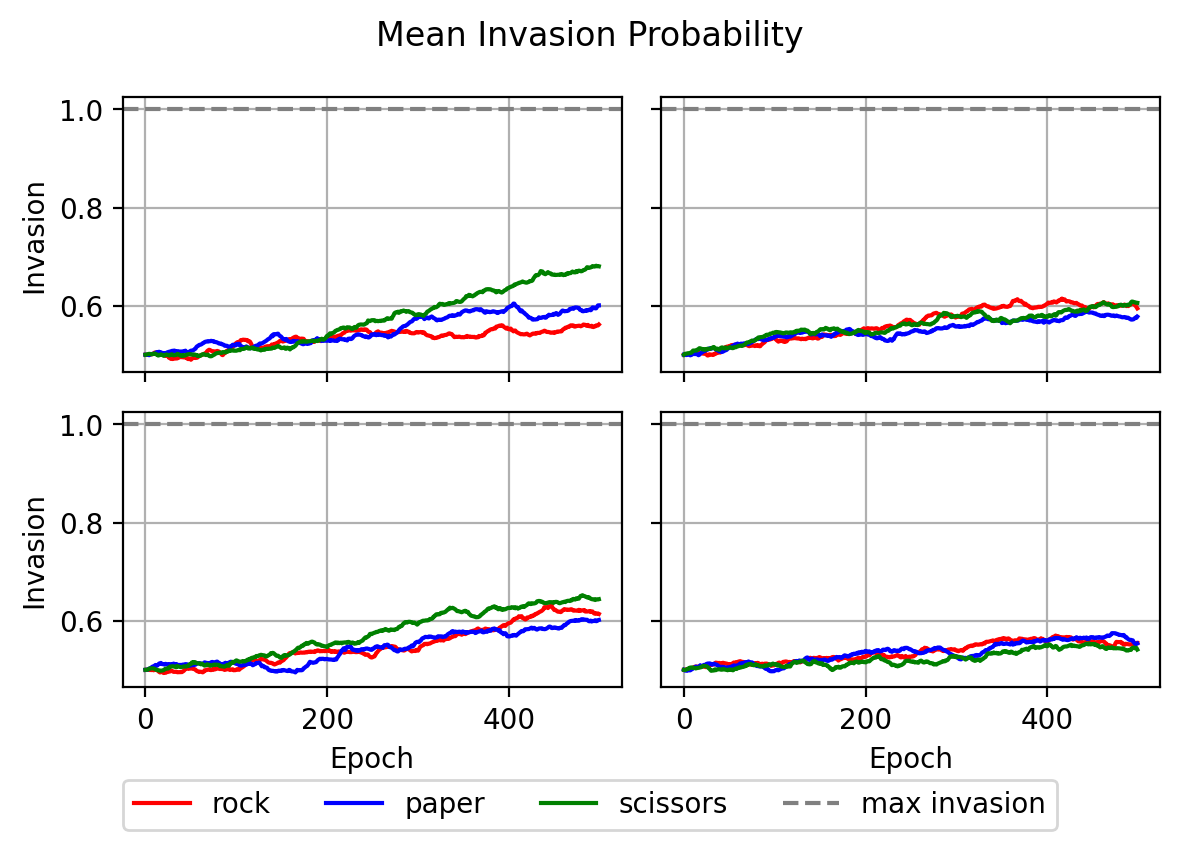

In [77]:
plot_average_invasions(g3_r10_df)

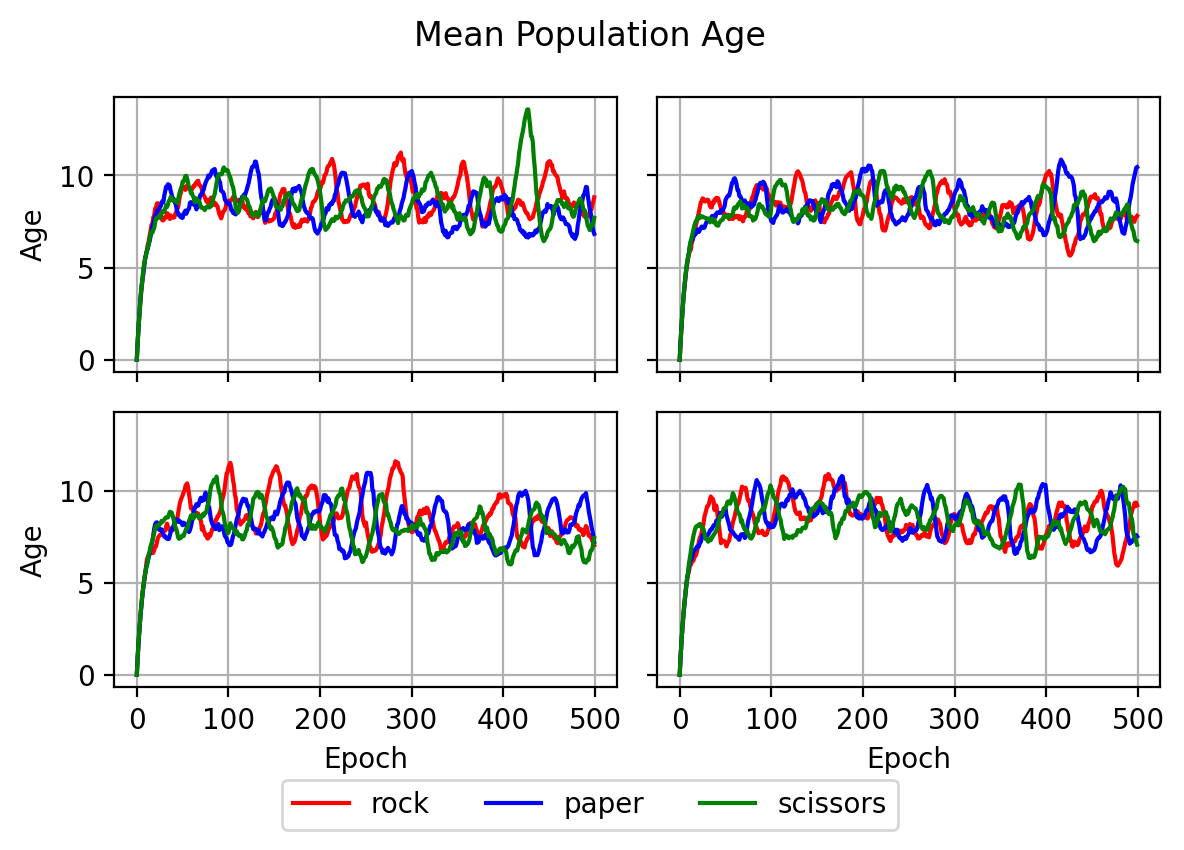

In [82]:
plot_average_age(g3_r10_df)

In [84]:
g3_r20_df = pd.read_csv("results/genetic3_r20.csv")
g3_r20_df

,R_density,P_density,S_density,R_invasion,P_invasion,S_invasion,R_age,P_age,S_age,epoch,seed,grid_dim,R_init_invasion,P_init_invasion,S_init_invasion,R_policy,P_policy,S_policy,sigma,radius
0,799,863,838,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1,773,869,858,0.499699,0.499889,0.500596,1.000000,1.000000,1.000000,1,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
2,785,843,872,0.500873,0.499733,0.501500,1.842038,1.865955,1.845183,2,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
3,784,823,893,0.500800,0.500000,0.501870,2.567602,2.599028,2.569989,3,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
4,826,807,867,0.500645,0.498785,0.502410,3.184019,3.314746,3.256055,4,0,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,667,741,1092,0.589864,0.623762,0.605007,6.485757,7.630229,7.849817,495,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1996,673,718,1109,0.589775,0.624703,0.606103,6.591382,7.486072,7.885482,496,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1997,703,686,1111,0.589459,0.624847,0.606745,6.510669,7.572886,8.107111,497,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20
1998,728,669,1103,0.589641,0.627286,0.605730,6.414835,7.476831,8.258386,498,3,50,0.5,0.5,0.5,genetic,genetic,genetic,0.05,20


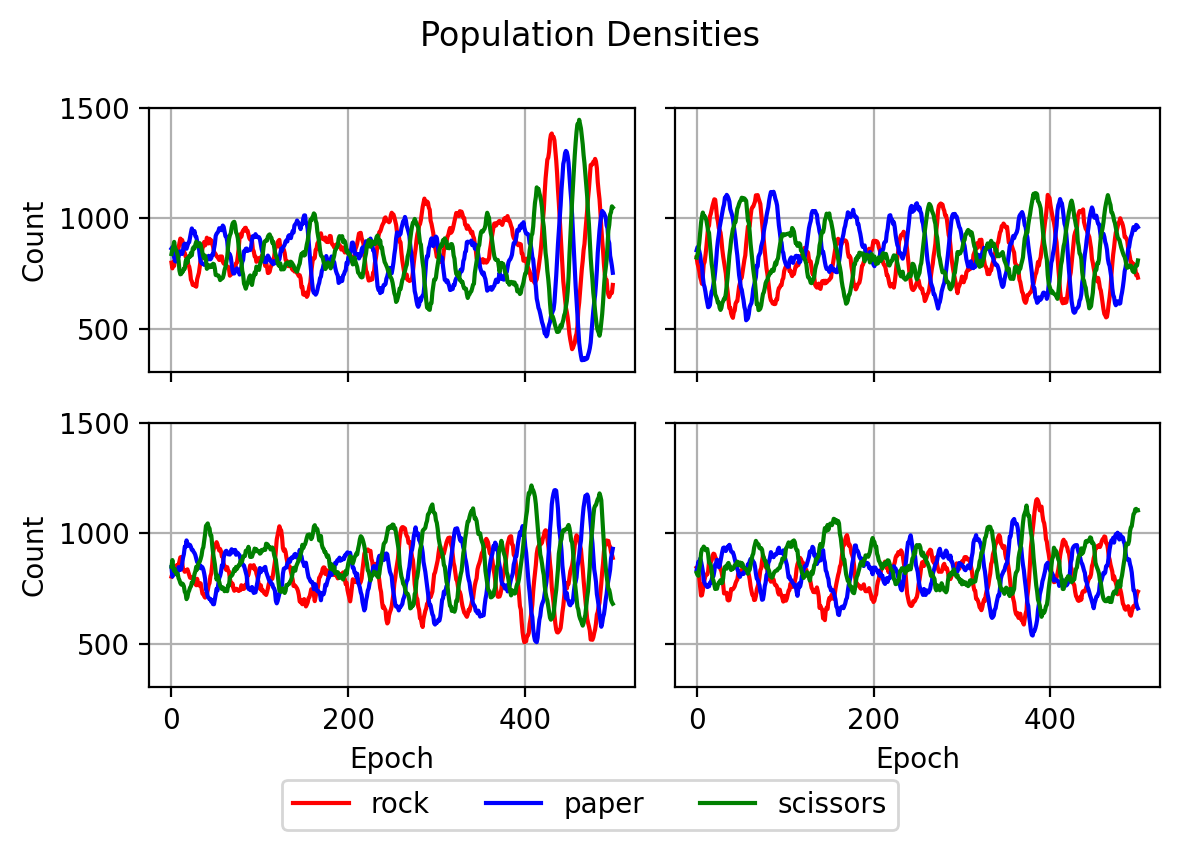

In [85]:
plot_densities(g3_r20_df)

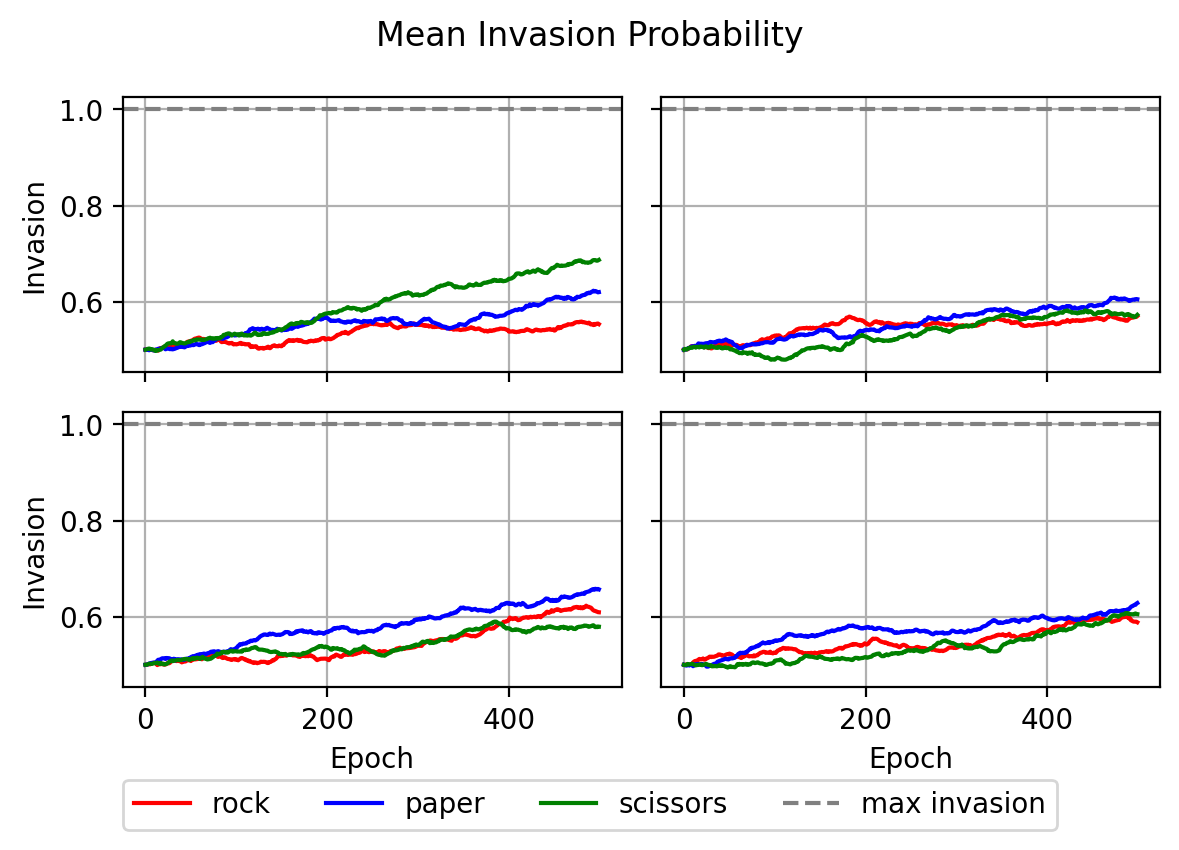

In [86]:
plot_average_invasions(g3_r20_df)

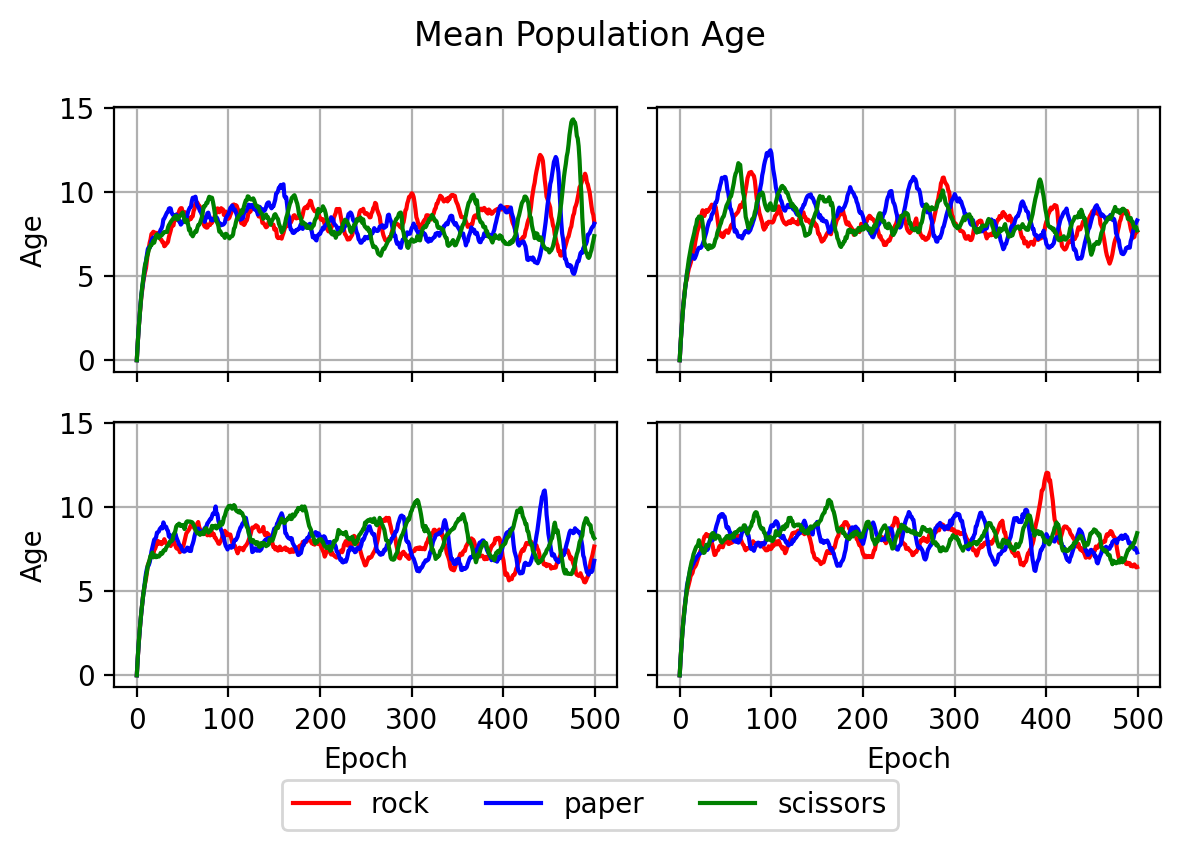

In [87]:
plot_average_age(g3_r20_df)

## Comparisons

Reasonable metrics to compare are